# Quality Evaluation Results


In [35]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from plot_utils import colors, set_plot_style, set_legend_style

RESULTS_DIR = os.path.join('results', 'quality', 'front')
RESULTS_TURNTABLE_DIR = os.path.join('results', 'quality', 'turntable')

In [36]:
set_plot_style()

In [37]:
results = {}

for filename in os.listdir(os.path.join(RESULTS_DIR, 'path_tracing')):
    volume, extinction, transfer_function = filename[:-4].rsplit('_', 2)
    results[(volume, int(extinction), int(transfer_function))] = {
        'path_tracing': pd.read_csv(
            os.path.join(RESULTS_DIR, 'path_tracing', filename)
        ),
        'neural_render': pd.read_csv(
            os.path.join(RESULTS_DIR, 'neural_render', filename)
        ),
    }

results_turntable = {}
for filename in os.listdir(os.path.join(RESULTS_TURNTABLE_DIR, 'path_tracing')):
    _, angle, volume, extinction, transfer_function = filename[:-4].split('_')
    results_turntable[(volume, int(angle), int(extinction), int(transfer_function))] = {
        'path_tracing': pd.read_csv(
            os.path.join(RESULTS_TURNTABLE_DIR, 'path_tracing', filename)
        ),
        'neural_render': pd.read_csv(
            os.path.join(RESULTS_TURNTABLE_DIR, 'neural_render', filename)
        ),
    }

## Plots

In [38]:
def plot_quality_metrics(results, volume, extinction, transfer_function, metric):
    pt = results[(volume, extinction, transfer_function)]['path_tracing']
    nr = results[(volume, extinction, transfer_function)]['neural_render']

    runs = len(pt['run'].unique())

    # Use the smallest run size to handle timing differences
    min_n_pt = pt.groupby('run').size().min()
    min_n_nr = nr.groupby('run').size().min()
    n = min(min_n_pt, min_n_nr)

    # Trim each run to n rows, then concatenate
    pt = pd.concat([grp.iloc[:n] for _, grp in pt.groupby('run')]).reset_index(
        drop=True
    )
    nr = pd.concat([grp.iloc[:n] for _, grp in nr.groupby('run')]).reset_index(
        drop=True
    )

    times = pt[pt['run'] == pt['run'].unique()[0]]['time'].to_numpy()

    stats_pt = (
        pt[[metric + '_global', metric + '_indirect']].to_numpy().reshape(runs, n, 2)
    )
    stats_nr = (
        nr[[metric + '_global', metric + '_indirect']].to_numpy().reshape(runs, n, 2)
    )

    mu_pt = stats_pt.mean(axis=0)
    mu_nr = stats_nr.mean(axis=0)
    se_pt = stats_pt.std(axis=0) / np.sqrt(runs)
    se_nr = stats_nr.std(axis=0) / np.sqrt(runs)

    fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

    ax[0].plot(times, mu_pt[:, 0], label='Path Tracing')
    ax[0].fill_between(
        times, mu_pt[:, 0] - se_pt[:, 0], mu_pt[:, 0] + se_pt[:, 0], alpha=0.2
    )
    ax[0].plot(times, mu_nr[:, 0], label='Neural Render')
    ax[0].fill_between(
        times, mu_nr[:, 0] - se_nr[:, 0], mu_nr[:, 0] + se_nr[:, 0], alpha=0.2
    )
    ax[0].set_title('Global ' + metric.upper())
    ax[0].set_xlabel('Time [s]')
    ax[0].set_ylabel(metric.upper())
    ax[0].legend()

    ax[1].plot(times, mu_pt[:, 1], label='Path Tracing')
    ax[1].fill_between(
        times, mu_pt[:, 1] - se_pt[:, 1], mu_pt[:, 1] + se_pt[:, 1], alpha=0.2
    )
    ax[1].plot(times, mu_nr[:, 1], label='Neural Render')
    ax[1].fill_between(
        times, mu_nr[:, 1] - se_nr[:, 1], mu_nr[:, 1] + se_nr[:, 1], alpha=0.2
    )
    ax[1].set_title('Indirect ' + metric.upper())
    ax[1].set_xlabel('Time [s]')

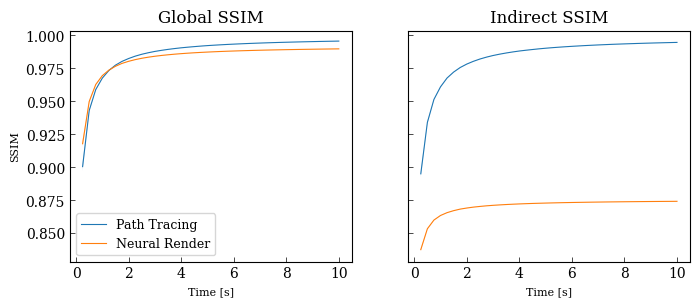

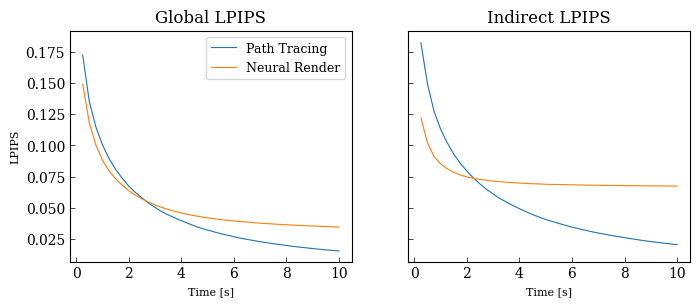

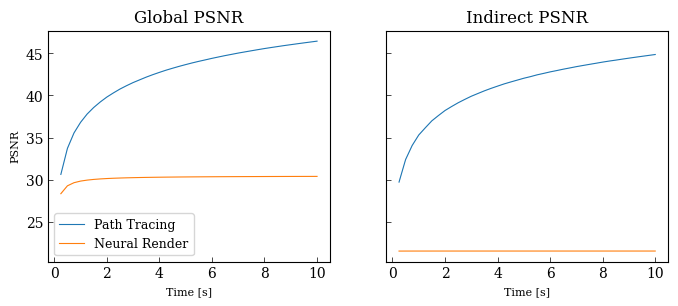

In [39]:
plot_quality_metrics(results, 'chameleon', 80, 3, 'ssim')
plot_quality_metrics(results, 'chameleon', 200, 3, 'lpips')
plot_quality_metrics(results, 'chameleon', 1000, 2, 'psnr')

In [40]:
def plot_turntable_quality_metrics(results_turntable, metric):
    angles = sorted({angle for _, angle, _, _ in results_turntable.keys()})
    times = [0.5, 10]

    mu_pt = np.zeros((len(angles), len(times), 2))
    mu_nr = np.zeros((len(angles), len(times), 2))
    se_pt = np.zeros((len(angles), len(times), 2))
    se_nr = np.zeros((len(angles), len(times), 2))

    for i, angle in enumerate(angles):
        pt = results_turntable[('chameleon', angle, 200, 3)]['path_tracing']
        nr = results_turntable[('chameleon', angle, 200, 3)]['neural_render']
        runs = len(pt['run'].unique())

        for j, time in enumerate(times):
            # Find the closest time entry for each run (there are some time variations)
            stats_pt = pt.groupby('run').apply(
                lambda g: g.iloc[(g['time'] - time).abs().argmin()][
                    [metric + '_global', metric + '_indirect']
                ]
            )
            stats_nr = nr.groupby('run').apply(
                lambda g: g.iloc[(g['time'] - time).abs().argmin()][
                    [metric + '_global', metric + '_indirect']
                ]
            )

            mu_pt[i, j] = stats_pt.mean()
            mu_nr[i, j] = stats_nr.mean()
            se_pt[i, j] = stats_pt.std() / np.sqrt(runs)
            se_nr[i, j] = stats_nr.std() / np.sqrt(runs)

    fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
    for j, time in enumerate(times):
        for k, metric_name in enumerate(['global', 'indirect']):
            ls = '--' if j == 0 else '-'

            ax[k].plot(
                angles,
                mu_pt[:, j, k],
                label=f'Path Tracing {time}s',
                ls=ls,
                c=colors[2],
            )
            ax[k].fill_between(
                angles,
                mu_pt[:, j, k] - se_pt[:, j, k],
                mu_pt[:, j, k] + se_pt[:, j, k],
                alpha=0.2,
                color=colors[2],
                edgecolor=None,
            )
            ax[k].plot(
                angles,
                mu_nr[:, j, k],
                label=f'Neural Render {time}s',
                ls=ls,
                c=colors[6],
            )
            ax[k].fill_between(
                angles,
                mu_nr[:, j, k] - se_nr[:, j, k],
                mu_nr[:, j, k] + se_nr[:, j, k],
                alpha=0.2,
                color=colors[6],
                edgecolor=None,
            )

    ax[0].set_title('Global ' + metric.upper())
    ax[1].set_title('Indirect ' + metric.upper())
    ax[0].set_xlabel('Angle [°]')
    ax[1].set_xlabel('Angle [°]')
    ax[0].set_ylabel(metric.upper())
    ax[0].set_xticks(angles[::2])
    ax[1].set_xticks(angles[::2])
    ax[0].set_xlim(angles[0], angles[-1])
    ax[1].set_xlim(angles[0], angles[-1])

    legend = ax[0].legend(ncols=4, loc='upper center', bbox_to_anchor=(1, -0.2))
    set_legend_style(legend)


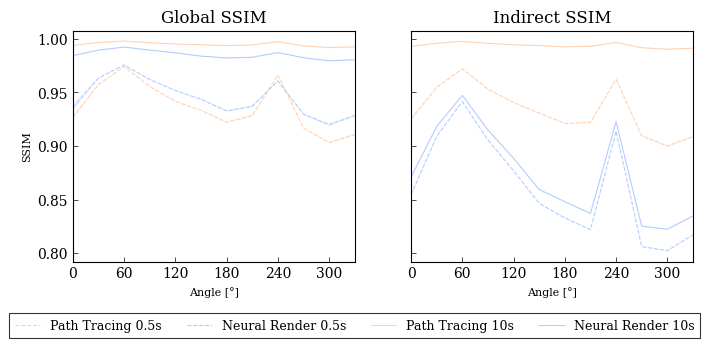

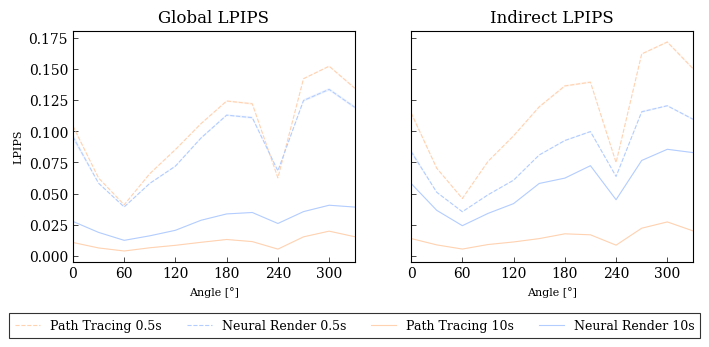

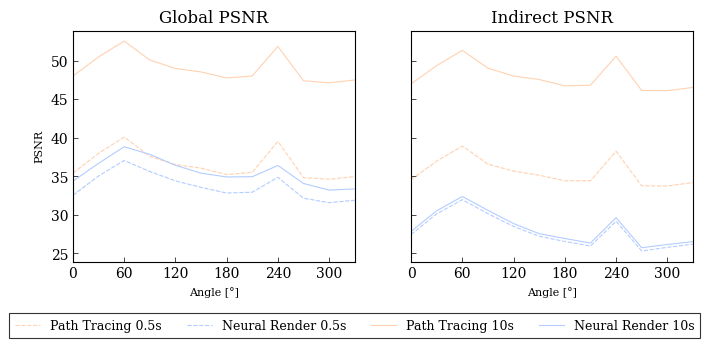

In [41]:
plot_turntable_quality_metrics(results_turntable, 'ssim')
plot_turntable_quality_metrics(results_turntable, 'lpips')
plot_turntable_quality_metrics(results_turntable, 'psnr')

## Table

In [42]:
def compute_metric(results, volume, extinction, transfer_function, column, time):
    pt = results[(volume, extinction, transfer_function)]['path_tracing']
    nr = results[(volume, extinction, transfer_function)]['neural_render']

    # Find the closest time entry for each run (there are some time variations)
    pt = pt.groupby('run').apply(lambda df: df.iloc[(df['time'] - time).abs().argmin()])
    nr = nr.groupby('run').apply(lambda df: df.iloc[(df['time'] - time).abs().argmin()])

    pt = pt[[column]]
    nr = nr[[column]]

    mu_pt = pt.mean().to_numpy()[0].item()
    mu_nr = nr.mean().to_numpy()[0].item()
    se_pt = (pt.std().to_numpy()[0] / np.sqrt(len(pt))).item()
    se_nr = (nr.std().to_numpy()[0] / np.sqrt(len(nr))).item()

    return (mu_pt, se_pt), (mu_nr, se_nr)

In [43]:
volumes = sorted({volume for volume, _, _ in results.keys()})
extinctions = sorted({extinction for _, extinction, _ in results.keys()})
transfer_functions = sorted(
    {transfer_function for _, _, transfer_function in results.keys()}
)


def print_volume_table(results, volume, extinctions, transfer_functions, time):
    print(f'Volume: {volume}')
    print(
        f'{"Ext.":<5} {"TF":<4} {"SSIM PT":<18} {"SSIM NR":<18} {"LPIPS PT":<18} {"LPIPS NR":<18} {"PSNR PT":<15} {"PSNR NR":<15}'
    )
    for extinction in extinctions:
        for transfer_function in transfer_functions:
            pt_ssim, nr_ssim = compute_metric(
                results, volume, extinction, transfer_function, 'ssim_global', time
            )
            pt_lpips, nr_lpips = compute_metric(
                results, volume, extinction, transfer_function, 'lpips_global', time
            )
            pt_psnr, nr_psnr = compute_metric(
                results, volume, extinction, transfer_function, 'psnr_global', time
            )

            print(
                f'{extinction:<5} {transfer_function:<4} '
                f'{pt_ssim[0]:.4f} ± {pt_ssim[1]:.4f}    '
                f'{nr_ssim[0]:.4f} ± {nr_ssim[1]:.4f}    '
                f'{pt_lpips[0]:.4f} ± {pt_lpips[1]:.4f}    '
                f'{nr_lpips[0]:.4f} ± {nr_lpips[1]:.4f}    '
                f'{pt_psnr[0]:.2f} ± {pt_psnr[1]:.2f}    '
                f'{nr_psnr[0]:.2f} ± {nr_psnr[1]:.2f}'
            )

In [44]:
print_volume_table(results, 'chameleon', extinctions, transfer_functions, 0.2)

Volume: chameleon
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
80    1    0.9284 ± 0.0016    0.9190 ± 0.0019    0.1562 ± 0.0016    0.1628 ± 0.0017    37.24 ± 0.12    35.47 ± 0.10
80    2    0.9378 ± 0.0011    0.9471 ± 0.0018    0.1254 ± 0.0013    0.1094 ± 0.0021    33.83 ± 0.09    34.11 ± 0.14
80    3    0.9005 ± 0.0034    0.9179 ± 0.0027    0.1427 ± 0.0021    0.1232 ± 0.0023    33.25 ± 0.19    32.32 ± 0.12
200   1    0.8964 ± 0.0014    0.8815 ± 0.0024    0.1671 ± 0.0013    0.1718 ± 0.0017    34.97 ± 0.09    32.73 ± 0.09
200   2    0.8926 ± 0.0013    0.9225 ± 0.0017    0.1600 ± 0.0010    0.1299 ± 0.0014    31.85 ± 0.08    33.24 ± 0.10
200   3    0.8509 ± 0.0010    0.8805 ± 0.0022    0.1721 ± 0.0008    0.1488 ± 0.0016    31.26 ± 0.05    31.12 ± 0.08
1000  1    0.8639 ± 0.0037    0.8405 ± 0.0035    0.1791 ± 0.0022    0.1778 ± 0.0021    33.35 ± 0.19    29.46 ± 0.09
1000  2    0.8080 ± 0.0016    0.8312 ± 0.0047    0.

In [45]:
print_volume_table(results, 'chameleon', extinctions, transfer_functions, 5)

Volume: chameleon
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
80    1    0.9941 ± 0.0000    0.9865 ± 0.0000    0.0222 ± 0.0002    0.0424 ± 0.0001    49.75 ± 0.02    39.61 ± 0.00
80    2    0.9954 ± 0.0000    0.9942 ± 0.0000    0.0124 ± 0.0001    0.0126 ± 0.0001    46.63 ± 0.01    40.28 ± 0.00
80    3    0.9922 ± 0.0000    0.9873 ± 0.0000    0.0164 ± 0.0001    0.0217 ± 0.0001    46.14 ± 0.01    35.93 ± 0.00
200   1    0.9909 ± 0.0000    0.9746 ± 0.0000    0.0314 ± 0.0002    0.0545 ± 0.0002    47.75 ± 0.01    36.25 ± 0.00
200   2    0.9910 ± 0.0000    0.9908 ± 0.0000    0.0248 ± 0.0002    0.0195 ± 0.0001    44.75 ± 0.01    39.34 ± 0.00
200   3    0.9853 ± 0.0000    0.9763 ± 0.0000    0.0323 ± 0.0002    0.0421 ± 0.0002    44.17 ± 0.01    34.87 ± 0.00
1000  1    0.9872 ± 0.0000    0.9568 ± 0.0000    0.0388 ± 0.0001    0.0663 ± 0.0002    46.35 ± 0.01    31.70 ± 0.00
1000  2    0.9775 ± 0.0001    0.9543 ± 0.0000    0.

In [46]:
print_volume_table(results, 'chameleon', extinctions, transfer_functions, 10)

Volume: chameleon
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
80    1    0.9966 ± 0.0000    0.9890 ± 0.0000    0.0100 ± 0.0001    0.0314 ± 0.0001    52.27 ± 0.01    39.79 ± 0.00
80    2    0.9974 ± 0.0000    0.9958 ± 0.0000    0.0058 ± 0.0001    0.0080 ± 0.0001    49.32 ± 0.01    40.64 ± 0.00
80    3    0.9957 ± 0.0000    0.9898 ± 0.0000    0.0077 ± 0.0000    0.0168 ± 0.0001    48.83 ± 0.01    36.08 ± 0.00
200   1    0.9949 ± 0.0000    0.9785 ± 0.0000    0.0152 ± 0.0001    0.0417 ± 0.0001    50.39 ± 0.01    36.39 ± 0.00
200   2    0.9950 ± 0.0000    0.9932 ± 0.0000    0.0117 ± 0.0001    0.0126 ± 0.0001    47.50 ± 0.01    39.70 ± 0.00
200   3    0.9919 ± 0.0000    0.9801 ± 0.0000    0.0156 ± 0.0001    0.0347 ± 0.0001    46.93 ± 0.01    35.03 ± 0.00
1000  1    0.9929 ± 0.0000    0.9623 ± 0.0000    0.0206 ± 0.0001    0.0538 ± 0.0002    49.05 ± 0.01    31.77 ± 0.00
1000  2    0.9875 ± 0.0000    0.9601 ± 0.0000    0.